In [52]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 

from sklearn.cluster import KMeans 
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.linear_model import LogisticRegression , LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score, confusion_matrix, mean_squared_error , r2_score)

In [53]:
df = pd.read_csv("Mall_Customers.csv")

In [54]:
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [55]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [56]:
df = df.drop(columns = ["CustomerID"] , errors = "ignore" )

In [57]:
df["Gender"] = df["Gender"].map({ "Male" : 0 , "Female":1})

In [58]:
df["High_Spender"] = (df["Spending Score (1-100)"] > 70).astype(int)

In [59]:
print(df.head())

   Gender  Age  Annual Income (k$)  Spending Score (1-100)  High_Spender
0       0   19                  15                      39             0
1       0   21                  15                      81             1
2       1   20                  16                       6             0
3       1   23                  16                      77             1
4       1   31                  17                      40             0


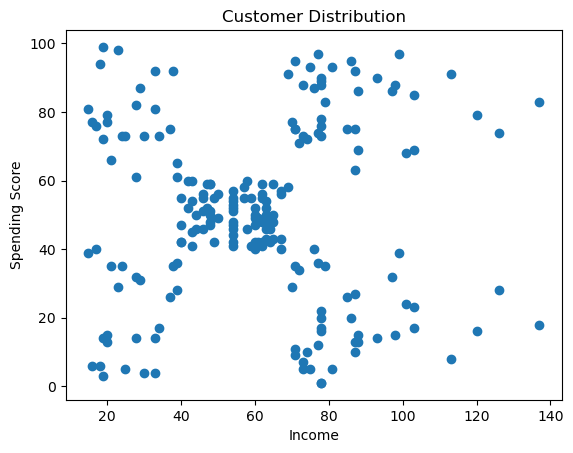

In [60]:


plt.scatter(df["Annual Income (k$)"] , df["Spending Score (1-100)"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Text(0.5, 1.0, 'Hierarchical')

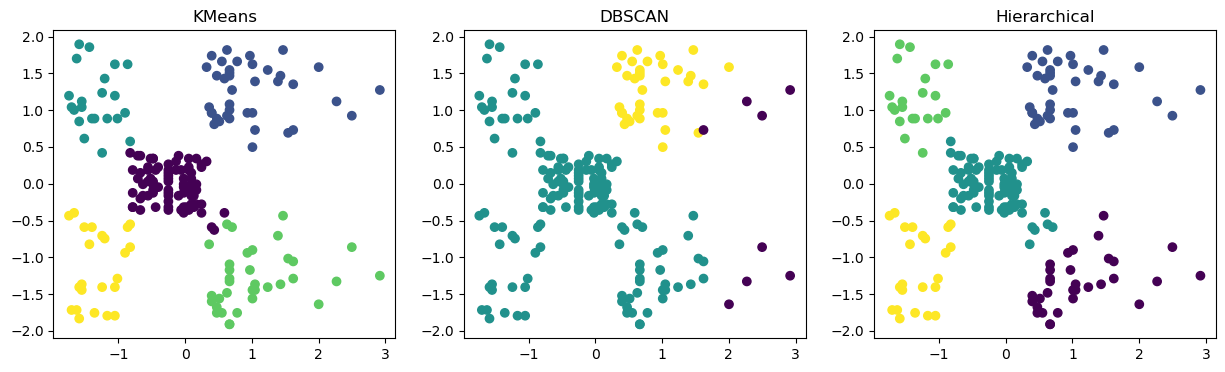

In [63]:

X = df[["Annual Income (k$)" , "Spending Score (1-100)"]]
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)
kmeans = KMeans(n_clusters=5 , random_state = 42)
labels_kmeans = kmeans.fit_predict(X_Scaled)

dbscan =  DBSCAN(eps=0.5 , min_samples =5)
labels_dbscan = dbscan.fit_predict(X_Scaled)

hc = AgglomerativeClustering(n_clusters=5)
labels_hc = hc.fit_predict(X_Scaled)


plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_kmeans)
plt.title("KMeans")

plt.subplot(1,3,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_dbscan)
plt.title("DBSCAN")

plt.subplot(1,3,3)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_hc)
plt.title("Hierarchical")



In [39]:
X1 = df.drop("High_Spender" , axis=1)
Y1 = df["High_Spender"]
X_train , X_test , Y_train, Y_test =  train_test_split(X1,Y1 ,test_size = 0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
lr= LogisticRegression()
rf = RandomForestClassifier()

lr.fit(X_train , Y_train)
rf.fit(X_train, Y_train)

print("Logistic:", accuracy_score(Y_test, lr.predict(X_test)))
print("Random Forest:", accuracy_score(Y_test, rf.predict(X_test)))

Logistic: 0.975
Random Forest: 1.0


In [40]:
### Predict Spendinf Score 
X2 = df.drop("Spending Score (1-100)" , axis = 1)
Y2 = df["Spending Score (1-100)"]

X2_train , X2_test , Y2_train , Y_test = train_test_split(X2,Y2,test_size = 0.2)
reg = LinearRegression()
reg.fit(X2_train , Y2_train)
y_pred = reg.predict(X2_test)

print("MSE:", mean_squared_error(Y_test, y_pred))


MSE: 142.42238254543778
